In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
games = pd.read_csv('/datasets/games.csv')

In [5]:
print(games.info())
print(games.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29

In [6]:
games.columns = games.columns.str.lower()
print(games.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


In [7]:
games['year_of_release'] = pd.to_numeric(games['year_of_release'])

In [8]:
games['user_score'] = games['user_score'].replace(['TBD', 'tbd'], pd.NA)
games['user_score'] = pd.to_numeric(games['user_score'])

In [9]:
#Las columnas year_of_release y user_score fueron convertidas a tipo numérico para permitir cálculos estadísticos.
#En el caso de user_score, algunos valores contenían la abreviatura "TBD" (to be determined), por lo que se reemplazaron por valores nulos antes de la conversión.

In [10]:
games.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [11]:
#Hay valores ausentes por juegos antiguos sin registros completos, por no tener reseña de usuarios o críticos, la clasificación ESRB no asignada a algunos juegos o errores de recopilación
#Los valores ausentes no fueron rellenados para no alterar el resultado del analisis, completarlos podría llevarnos a conclusiones erroneas

In [12]:
games['total_sales'] = (
    games['na_sales'] +
    games['eu_sales'] +
    games['jp_sales'] +
    games['other_sales']
)
games[['name', 'total_sales']].head()

,name,total_sales
0,Wii Sports,82.54
1,Super Mario Bros.,40.24
2,Mario Kart Wii,35.52
3,Wii Sports Resort,32.77
4,Pokemon Red/Pokemon Blue,31.38


In [13]:
#Se creó una nueva columna total_sales que representa la suma de las ventas en todas las regiones (NA, EU, JP y otras). Esto permite evaluar el éxito global de cada juego de manera más precisa.

In [14]:
#3 Analiza los datos

<AxesSubplot:title={'center':'Juegos lanzados por año'}, xlabel='year_of_release'>

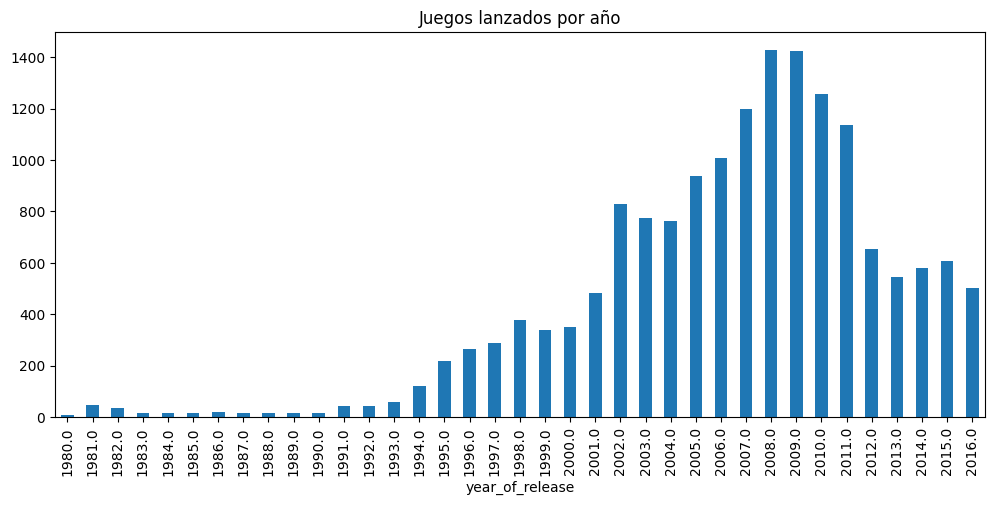

In [15]:
#3.1
games.groupby('year_of_release')['name'].count().plot(
    kind='bar', figsize=(12,5), title='Juegos lanzados por año')

In [16]:
#Aumento la cantidad de juego con el tiempo, con los picos más altos entre 2007 y 2010
#Los datos de los primeros años no son significativos debido al bajo número de lanzamientos. Los años más recientes contienen información más representativa

In [17]:
#3.2 Ventas por plataforma
platform_sales = (
    games.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
)
platform_sales

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       30.77
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64

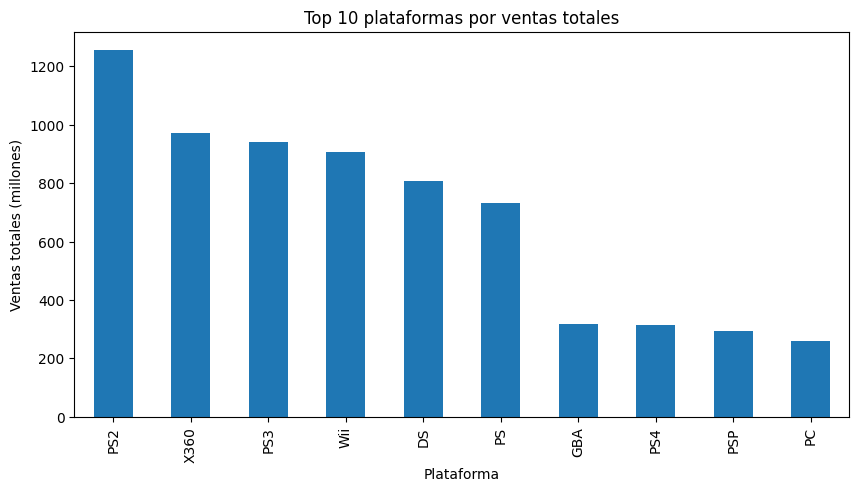

In [18]:
platform_sales.head(10).plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 plataformas por ventas totales'
)
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones)')
plt.show()

In [19]:
#Las plataformas que más venden son PS2, X360, PS3 Y WII
#Otras como PCFX, GG, 3D0 Y TG16 están desapareciendo

<AxesSubplot:xlabel='year_of_release'>

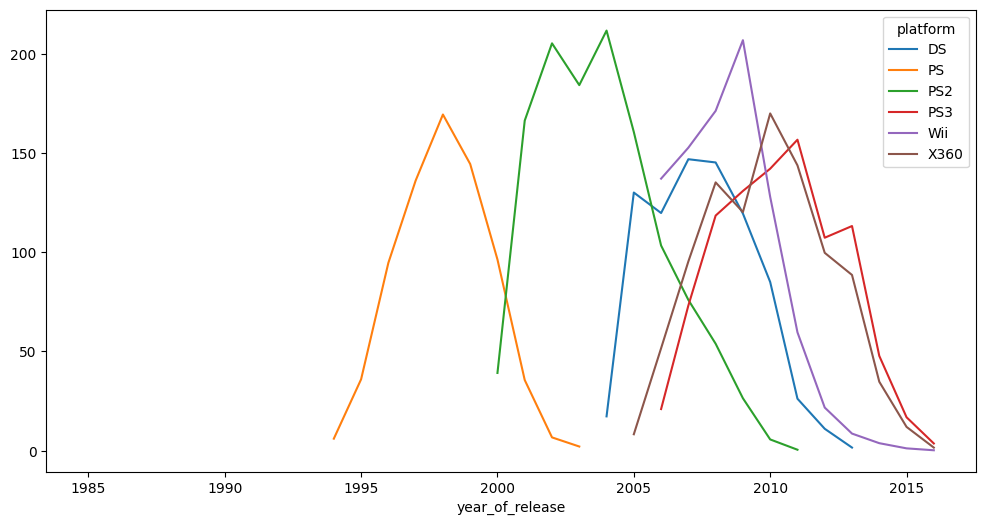

In [20]:
top_platforms = platform_sales.head(6).index

games.query('platform in @top_platforms').pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
).plot(figsize=(12,6))

In [21]:
# las plataformas más exitosas tienen un ciclo de vida de entre 7 y 10 años, pero el pico maximo de ventas es de al rededor de 5 años


In [22]:
#3.3 Periodos relevante
games_recent = games.query('year_of_release >= 2013')

In [23]:
#Se planea 2017 usando datos de 2016, considero que datos anteriores a 2013 ya no están actualizados y no demuestran como se comporta el mercado actualmente, ya que hay plataformas que ya no son relevantes

In [24]:
#3.4 plataformas lideres en ventas
games_recent.groupby('platform')['total_sales'] \
    .sum().sort_values(ascending=False)

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64

In [25]:
#Los lideres de ventas son PS4 y PS3, pero este esta en declive, mientras que Xone esta en crecimiento junto con PS4

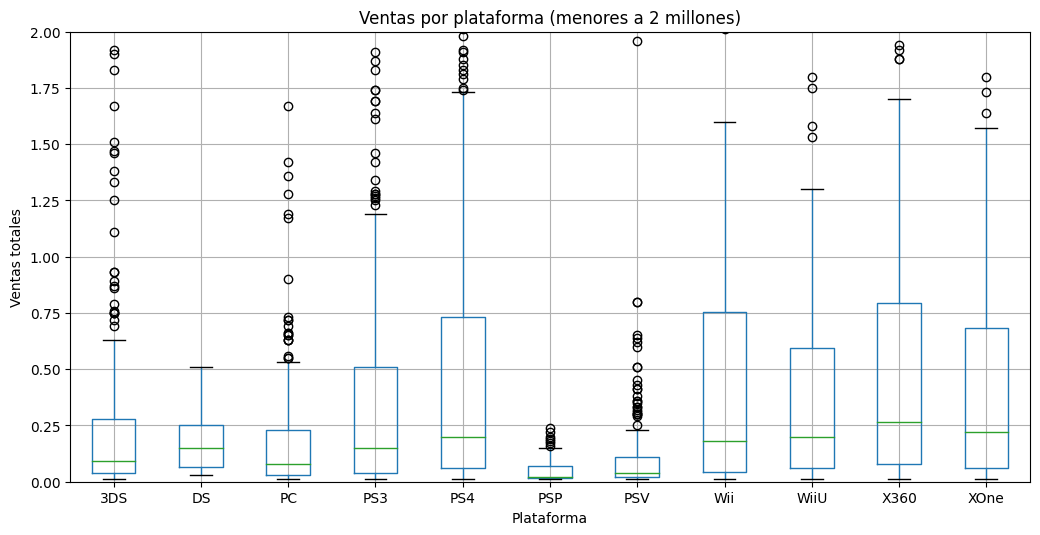

In [87]:
#3.5 Diagrama de caja
games_recent.boxplot(
    column = 'total_sales',
    by = 'platform',
    figsize= (12,6)
)
plt.ylim(0,2)
plt.title('Ventas por plataforma (menores a 2 millones)')
plt.suptitle('')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales')
plt.show()

In [88]:
#Las ventas globales menores a 2 millones por plataforma en a mayoría de los juegos presentan ventas relativamente bajas, sin importar la consola, pero PS4, XBOX 360, XONE Y WII muestran medianas más altas y mayor dispersión, que nos indica mejores ventas y más estables, las plataformas PSP, PSV Y DS tienen ventas más bajas y menor variabilidad, que nos indican un mercado limitado

<AxesSubplot:title={'center':'Críticas profesionales vs ventas (PS4)'}, xlabel='critic_score', ylabel='total_sales'>

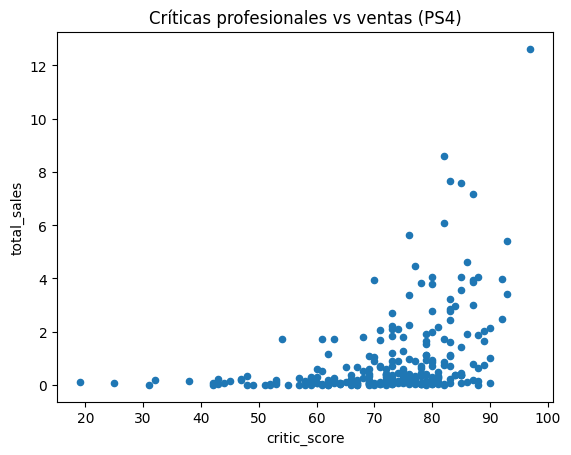

In [89]:
#3.6 Impacto de las reseñas
ps4 = games_recent.query('platform == "PS4"')
ps4.plot(
    x='critic_score',
    y='total_sales',
    kind='scatter',
    title='Críticas profesionales vs ventas (PS4)'
)

In [90]:
#Para analizar la relación entre reseñas y ventas se eligió la plataforma PS4, ya que es una de las más populares y relevantes en el período considerado
#El PS4 se encontraba en crecimiento en 2016 y los resultados van a ser representativos para planear el 2017

In [91]:
ps4[['critic_score', 'total_sales']].corr()

,critic_score,total_sales
critic_score,1.000000,0.406568
total_sales,0.406568,1.000000


In [92]:
#El análisis de correlación muestra que existe una relación positiva moderada (0.40) entre la puntuación de los críticos profesionales y las ventas totales, lo que indica que los juegos con mejores críticas tienden a vender más.Pero no es el único factor a tomar en cuenta

In [93]:
ps4[['user_score', 'total_sales']].corr()

,user_score,total_sales
user_score,1.000000,-0.031957
total_sales,-0.031957,1.000000


In [94]:
#la correlación entre la puntuación de los usuarios y las ventas totales es prácticamente nula, lo que sugiere que las opiniones de los usuarios no tienen un impacto significativo en las ventas.

In [103]:
#3.7 Compara las ventas de los mismo juego en otras plataformas
ventas_por_juego = games_recent.groupby('name')['total_sales'].sum()
top_5_juegos = ventas_por_juego.nlargest(5).index

datos_top_juegos = games_recent[games_recent['name'].isin(top_5_juegos)]

comparacion_plataformas = datos_top_juegos.pivot_table(
    index='name',
    columns='platform', 
    values='total_sales',
    aggfunc='sum',
)

comparacion_plataformas

platform,PC,PS3,PS4,PSV,WiiU,X360,XOne
name,,,,,,,
Call of Duty: Advanced Warfare,0.41,4.36,7.66,NaN,NaN,4.28,5.26
Call of Duty: Black Ops 3,0.26,1.69,14.63,NaN,NaN,1.70,7.39
Call of Duty: Ghosts,0.69,9.36,3.83,NaN,0.35,10.24,2.92
Grand Theft Auto V,1.17,21.05,12.62,NaN,NaN,16.27,5.47
Minecraft,NaN,5.27,4.32,1.96,0.67,9.18,2.76


In [96]:
#No solo el título del videojuego es importante para garantizar el exito, también es importante la p´lataforma donde se lanzo, siendo las plataformas de sobremesa las que presentan la mejores ventas, priorizar estas plataformas es imoprtante para el 2017

In [112]:
#3.8 distribución de los juegos por genero
ventas_promedio_por_genero = games_recent.groupby('genre')['total_sales'].mean()
generos_ordenados = ventas_promedio_por_genero.sort_values(ascending=False)
print(f"Ventas en millones:{generos_ordenados.round(2)}")

Ventas en millones:genre
Shooter         1.25
Sports          0.70
Platform        0.58
Role-Playing    0.50
Racing          0.47
Fighting        0.44
Action          0.42
Misc            0.41
Simulation      0.35
Puzzle          0.19
Strategy        0.18
Adventure       0.10
Name: total_sales, dtype: float64


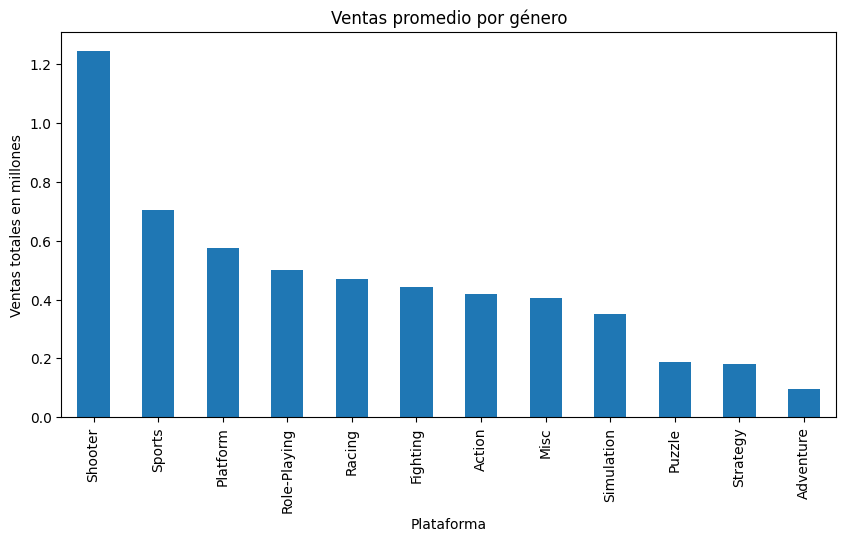

In [113]:
generos_ordenados.plot(
    kind='bar',
    figsize=(10,5),
    title='Ventas promedio por género'
)
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales en millones')
plt.show()

In [98]:
#Los generos con mejores ventas son aquellos de acción, juegos competitivos, mientras que juegos más lentos tienen menores ventas

In [ ]:
#Desde el punto de vista de rentabilidad promedio por juego, los géneros Shooter y Sports resultan más atractivos que otros géneros con mayores ventas totales, como Action, esto resalta la importancia de analizar el total de ventas y como el desempeño promedio

In [38]:
#Conlcusiones del paso 3
#El mercado no es estable, esta en constante movimiento
#PS4 Y XOne son las más prometedoras para el año 2017
#Una buena critica ayuda a tener mejores ventas
#Los juegos de acción y shooter son amplios favoritos

In [39]:
#Paso 4 Perfil de usuario para cada región

In [40]:
games_recent = games.query('year_of_release >= 2013')

In [41]:
#Para el analisis por región solo se va a tomar en cuenta datos a partir del 2013, ya que son datos importantes para la planeación del 2017, datos anteriores no son relevantes por lo cambiante que es el mercado

In [42]:
#4.1 top 5 Plataformas NA

In [43]:
sales_na = games_recent.groupby('platform')['na_sales'].sum()
ascending_platform = sales_na.sort_values(ascending=False)
top_5_na = ascending_platform.head(5)
print(top_5_na)

platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64


In [44]:
#El mercado norteamericano prefiere las consolas más mpdernas, el PSA y Xone

In [45]:
#Top 5 géneros

In [46]:
genre_na = games_recent.groupby('genre')['na_sales'].sum()
ascending_genre = genre_na.sort_values(ascending=False)
top_5_genres = ascending_genre.head(5)
print(top_5_genres)

genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64


In [47]:
#Los generos de acción y disparos dominan el mercado norteamericano, juegos más competitivos y dinámicos 

In [48]:
# Esrb

In [49]:
esrb_na = games_recent.groupby('rating')['na_sales'].sum()
ascending_esrb_na = esrb_na.sort_values(ascending=False)
print(ascending_esrb_na)

rating
M       165.21
E        79.05
E10+     54.24
T        49.79
Name: na_sales, dtype: float64


In [50]:
#Los juegos más comprados según esta clasificación son de adultos y para todos, pero la clasificación en NA es relevante, al no tener tantos valoresa ausentes

In [51]:
#4.2 Top 5 plataformas EU

In [52]:
sales_eu = games_recent.groupby('platform')['eu_sales'].sum()
ascending_platform_eu = sales_eu.sort_values(ascending=False)
top_5_eu = ascending_platform_eu.head(5)
print(top_5_eu)

platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64


In [53]:
#En el mercado europeo tienen preferencias por las cosolas de Play Station, incluso teniendo la consola más nueva de Xbox

In [54]:
#Top 5 géneros

In [55]:
genre_eu = games_recent.groupby('genre')['eu_sales'].sum()
ascending_genre_eu = genre_eu.sort_values(ascending=False)
top_5_genres_eu = ascending_genre_eu.head(5)
print(top_5_genres_eu)

genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64


In [56]:
#De nuevo los generos que dominan son los de acción y disparos, pero la preferencia por los juegos de acción por encima de los shooter es mayor que en Na

In [57]:
# Esrb

In [58]:
esrb_eu = games_recent.groupby('rating')['eu_sales'].sum()
ascending_esrb_eu = esrb_eu.sort_values(ascending=False)
print(ascending_esrb_eu)

rating
M       145.32
E        83.36
E10+     42.69
T        41.95
Name: eu_sales, dtype: float64


In [59]:
#Las ventas también estan centradas en la clasificación de adultos y para todos

In [60]:
#4.3 Top 5 plataformas JP

In [61]:
sales_jp = games_recent.groupby('platform')['jp_sales'].sum()
ascending_platform_jp = sales_jp.sort_values(ascending=False)
top_5_jp = ascending_platform_jp.head(5)
print(top_5_jp)

platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64


In [62]:
#El mercado japonés es muy diferente, con una preferencia por consolas portatiles y por consolas de origen japonés

In [63]:
#Top 5 generos

In [64]:
genre_jp = games_recent.groupby('genre')['jp_sales'].sum()
ascending_genre_jp = genre_jp.sort_values(ascending=False)
top_5_genres_jp = ascending_genre_jp.head(5)
print(top_5_genres_jp)

genre
Role-Playing    51.04
Action          40.49
Misc             9.20
Fighting         7.65
Shooter          6.61
Name: jp_sales, dtype: float64


In [65]:
#Aquí la preferencia es por juegos de rol, pero los juegos de acción no dejan de ser relevantes, hay diferencias culturales marcadas

In [66]:
#ESRB

In [67]:
esrb_jp = games_recent.groupby('rating')['jp_sales'].sum()
ascending_esrb_jp = esrb_jp.sort_values(ascending=False)
print(ascending_esrb_jp)

rating
T       20.59
E       15.14
M       14.11
E10+     5.89
Name: jp_sales, dtype: float64


In [68]:
#Si analisamos hay muchos valores ausentes y esto nos dice que el ESRB es menos relevante en Japón

In [69]:
#Paso 5 Prueba las siguientes hipótesis:

In [70]:
#Hipotesis
#Las calificaciones promedio de los usuarios para Xbox One y PC son las mismas

In [71]:
#Hipotesis nula (Ho)
#La calificación promedio de los usuarios en Xbox One es igual a la de PC
#Hipotesis alterna (H1)
#La calificación promedio de los usuarios en Xbox One es diferente a la de PC

In [72]:
juegos_xone = games_recent[games_recent['platform'] == 'XOne']
xone_scores = juegos_xone[juegos_xone['user_score'].notna()]['user_score']

juegos_pc = games_recent[games_recent['platform'] == 'PC']
pc_scores = juegos_pc[juegos_pc['user_score'].notna()]['user_score']

In [73]:
alpha = 0.05

results = stats.ttest_ind(
    xone_scores,
    pc_scores,
    equal_var=False
)

print("valor p:" , results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No rechazamos la hipótesis nula")

valor p: 0.14759594013430463
No rechazamos la hipótesis nula


In [74]:
#Se realizó una prueba t de Student para comparar dos medias y son muestras independientes, se comparó las calificaciones promedio de los usuarios entre Xbox One y PC, con un nivel de significación de 0.05, no se encontraron diferencias estadísticamente significativas entre las medias, por lo que no se rechazó la hipótesis nula
#No hay evidencia estadística suficiente para afirmar que las medias sean distintas

In [75]:
# Hipótesis 2
#Las calificaciones promedio de los usuarios para los géneros acción y deportes son diferentes

In [76]:
#Hipótesis nula (Ho)
#La calificación promedio de los usuarios para los juegos de acción es igual a la de deportes
#Hipótesis alternativa (H1)
#La clasificación promedio de los usuarios para los juegos de acción y deporte es diferente

In [77]:
action = games_recent[games_recent['genre'] == 'Action']
action_score = action[action['user_score'].notna()]['user_score']

sports = games_recent[games_recent['genre'] == 'Sports']
sports_score = sports[sports['user_score'].notna()]['user_score']

In [78]:
alpha = 0.05

results = stats.ttest_ind(
    action_score,
    sports_score,
    equal_var=False
)

print("valor p:" , results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No rechazamos la hipótesis nula")

valor p: 1.4460039700704315e-20
Rechazamos la hipótesis nula


In [79]:
#Para comparar las calificaciones promedio de los usuarios entre los géneros acción y deportes se aplicó una prueba t de Student, con un nivel de significación de 0.05, se encontró una diferencia estadísticamente significativa entre ambos géneros, por lo que se rechazó la hipótesis nula
#Los usuarios califican de forma distinta los juegos de aacción y deporte

In [80]:
#Paso 6 
#En este proyecto se analizaron datos de las ventas de videojuegos, reseñas, géneros, plataformas y clasificación ESRB con el objetivo de estimar el exito de juegos y plataformas y planear el año 2017
#El análisis muestra que las plataformas tienen un ciclo de vida limitado, a partir de 2013 la elección se dirige a consolas de nueva generación (PS4 Y Xone), mientras que consolas anteriores estaban en declive, con un ciclo de vida entre 7 y 10 años
#Los generos de acción, shooter y deporte tiene las mayores ventas globales, es una buena área de mercado y los géneros con menores ventas son puzzle o de estrategia
#La calificación de los criticos profesionales influye en las ventas, mientras que la calificación de los usuarios no afecta directamente a las ventas
#Hay diferencias regionales significativas, NA y EU tienen preferencia por consolas de sobremesa y juegos de ación, mientras que Japón prefiere consolas portatiles y de origen japones, con preferencia en juegos de rol. Es necesario adoptar la publicidad necesaria a cada región
#Finalmente las pruebas de hipótesis permite confirmar que existen diferencias significativas entre género, mientras que algunas plataformas presentan calificaciones de usuarios similares
#En conjunto, los resultados indican que para 2017 los proyectos más prometedores son aquellos desarrollados para PS4 y XOne, generos preferidos por cada región, respaldados por una buena reseña por profesionales y con campañas publicitarias dirigidas a cada región